In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bike-sharing-demand/sampleSubmission.csv
/kaggle/input/bike-sharing-demand/train.csv
/kaggle/input/bike-sharing-demand/test.csv


# **Prepare Data**

In [2]:
!pip install autogluon.tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 51.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 22.0.0
    Uninstalling pyarrow-22.0.0:
      Successfully uninstalled pyarrow-22.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.4.2 requires pyarrow>=21.0.0, but you have pyarrow 20.0.0 which is incomp

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from autogluon.tabular import TabularPredictor
import zipfile
warnings.filterwarnings("ignore")

In [4]:
train_df = pd.read_csv('/kaggle/input/bike-sharing-demand/train.csv')
test_df = pd.read_csv('/kaggle/input/bike-sharing-demand/test.csv')
sam_sub = pd.read_csv('/kaggle/input/bike-sharing-demand/sampleSubmission.csv')

# **Explore Data**

## Raw Data

In [5]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [7]:
sam_sub.head()

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0


In [8]:
print(train_df.info())
print('-------------')
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None
-------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1  

## Statistic

In [9]:
train_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


## Balance

<Axes: xlabel='count', ylabel='count'>

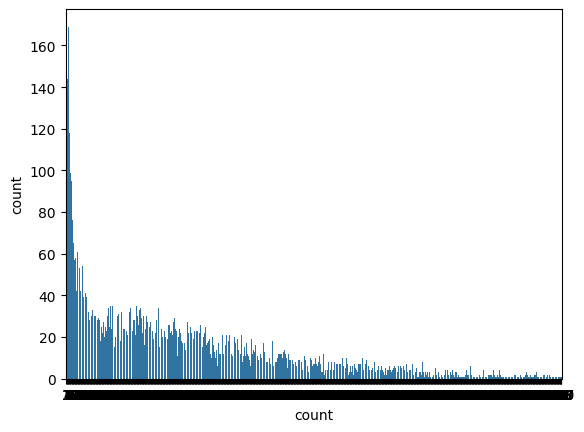

In [10]:
sns.countplot(data=train_df,x='count')

## Duplicate

In [11]:
features = train_df.columns.values[1:9]
train_dp = []
test_dp = []
for i in features:
    f = train_df[i].value_counts()
    train_dp.append([i,f.max(),f.idxmax()])
    f = test_df[i].value_counts()
    test_dp.append([i,f.max(),f.idxmax()])
train_dp = pd.DataFrame(train_dp,columns=['features','dup','value'])
test_dp = pd.DataFrame(test_dp,columns=['features','dup','value'])

In [12]:
train_dp

,features,dup,value
0,season,2734,4.00
1,holiday,10575,0.00
2,workingday,7412,1.00
3,weather,7192,1.00
4,temp,467,14.76
5,atemp,671,31.06
6,humidity,368,88.00
7,windspeed,1313,0.00


In [13]:
test_dp

,features,dup,value
0,season,1763,3.00
1,holiday,6304,0.00
2,workingday,4453,1.00
3,weather,4221,1.00
4,temp,323,25.42
5,atemp,317,31.06
6,humidity,314,83.00
7,windspeed,867,0.00


# **Analysis Data**

## Raw Data

array([[<Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'workingday'}>],
       [<Axes: title={'center': 'weather'}>,
        <Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>],
       [<Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'casual'}>],
       [<Axes: title={'center': 'registered'}>,
        <Axes: title={'center': 'count'}>, <Axes: >]], dtype=object)

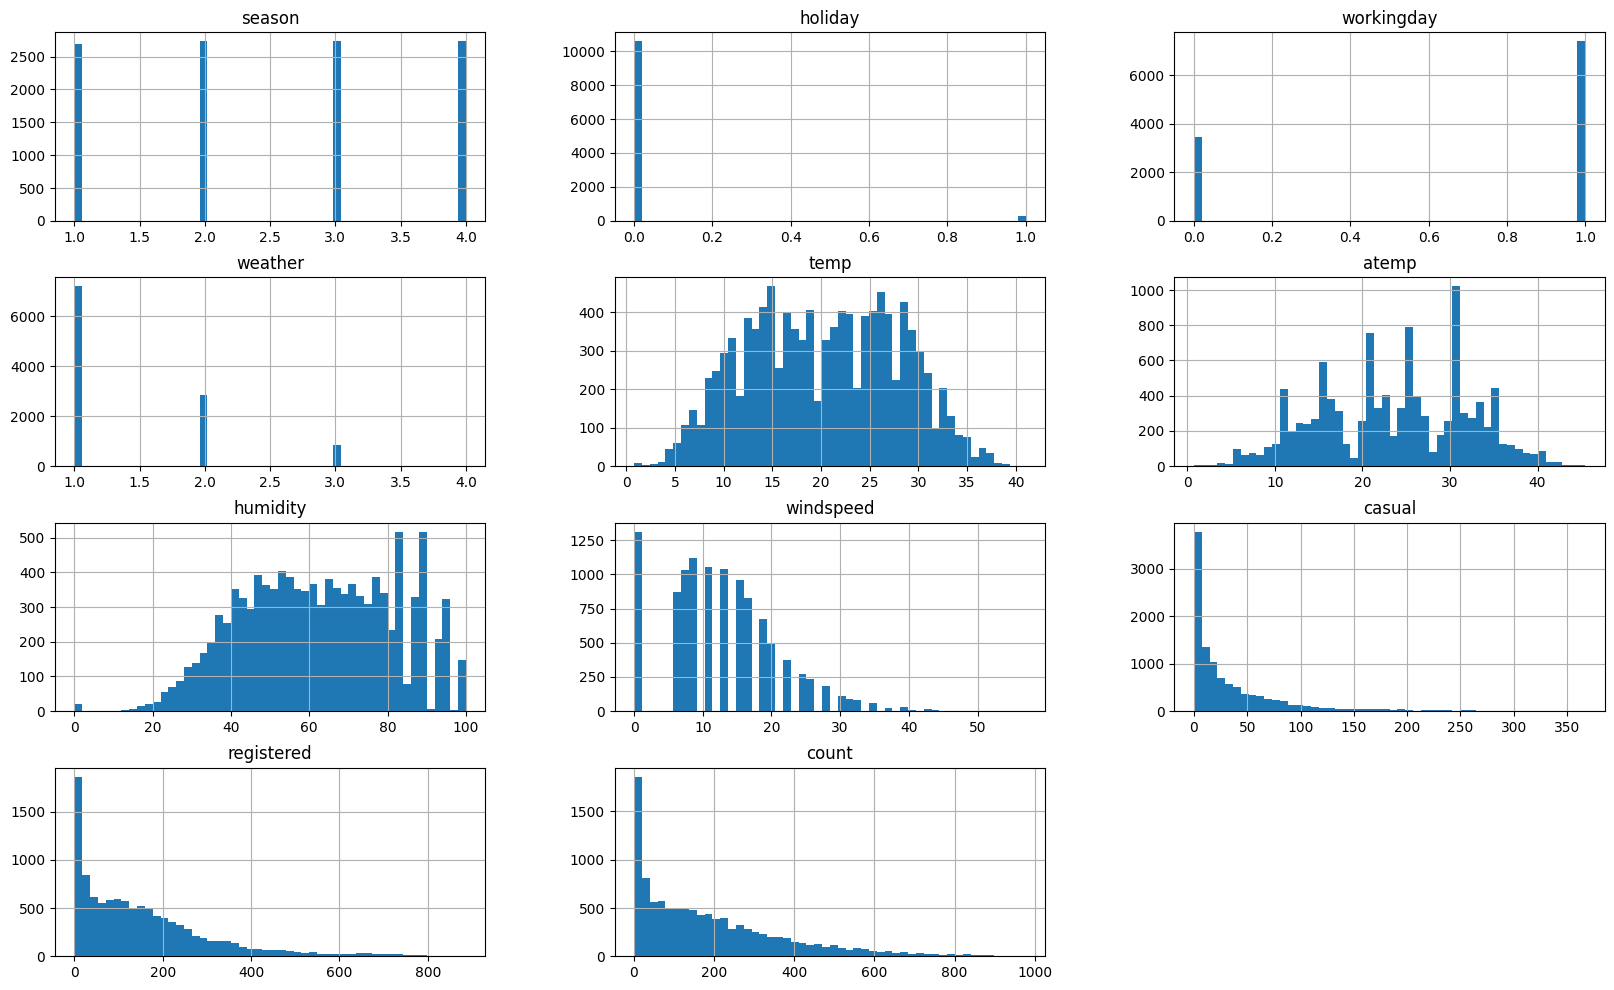

In [14]:
train_df.hist(bins=50,figsize=(20,12))

# **Model**

In [15]:
train_df = train_df.drop(columns='casual')
train_df = train_df.drop(columns='registered')
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1


In [16]:
label = 'count' 
metric = 'root_mean_squared_error'  

predictor = TabularPredictor(label=label, eval_metric=metric).fit(
    train_data=train_df,
    presets='best_quality',
    time_limit=3600
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260209_124506"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Jan 17 11:20:45 UTC 2026
CPU Count:          4
Pytorch Version:    2.8.0+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 15.89/15.89 GB
Total GPU Memory:   Free: 15.89 GB, Allocated: 0.00 GB, Total: 15.89 GB
GPU Count:          1
Memory Avail:       29.79 GB / 31.35 GB (95.0%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True

# **Evaluate**

In [17]:
predictor.leaderboard(train_df, silent=True)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestMSE_BAG_L1,-42.939157,-116.548359,root_mean_squared_error,0.379072,0.502651,6.670928,0.379072,0.502651,6.670928,1,True,1
1,WeightedEnsemble_L2,-45.620372,-116.531851,root_mean_squared_error,0.756057,0.610915,588.521333,0.001939,0.000465,0.023476,2,True,11
2,ExtraTreesMSE_BAG_L1,-45.921107,-124.600676,root_mean_squared_error,0.373596,0.488456,3.056535,0.373596,0.488456,3.056535,1,True,3
3,NeuralNetTorch_r79_BAG_L2,-57.162644,-115.932777,root_mean_squared_error,5.032225,1.853070,2121.744432,0.480495,0.137967,325.805371,2,True,19
4,WeightedEnsemble_L3,-60.135769,-112.901789,root_mean_squared_error,7.463555,2.751932,2347.737303,0.002921,0.000471,0.037631,3,True,21
5,NeuralNetTorch_BAG_L2,-60.978704,-117.054935,root_mean_squared_error,4.965078,1.845480,2077.551233,0.413347,0.130378,281.612171,2,True,17
6,NeuralNetFastAI_r191_BAG_L2,-61.353267,-114.241735,root_mean_squared_error,5.684434,1.892814,1933.309430,1.132704,0.177712,137.370368,2,True,20
7,RandomForestMSE_BAG_L2,-61.493166,-117.599156,root_mean_squared_error,4.968355,2.308730,1822.241527,0.416625,0.593627,26.302466,2,True,12
8,CatBoost_r177_BAG_L2,-62.221026,-115.005200,root_mean_squared_error,4.607596,1.738202,1812.021989,0.055866,0.023099,16.082928,2,True,18
9,CatBoost_BAG_L2,-62.851931,-115.061933,root_mean_squared_error,4.613375,1.738783,1816.793466,0.061645,0.023680,20.854404,2,True,13


In [18]:
predictor.evaluate(train_df)

{'root_mean_squared_error': np.float64(-60.13576893024479),
 'mean_squared_error': -3616.310791015625,
 'mean_absolute_error': -32.65003967285156,
 'r2': 0.8897812366485596,
 'pearsonr': 0.9514135114658144,
 'median_absolute_error': np.float64(-15.942546844482422)}

# **Submission**

In [19]:
predictions = predictor.predict(test_df)

In [20]:
submission = pd.DataFrame({
    'datetime': test_df['datetime'],
    'count': predictions
})

In [21]:
submission.head()

,datetime,count
0,2011-01-20 00:00:00,89.630920
1,2011-01-20 01:00:00,90.559669
2,2011-01-20 02:00:00,90.560371
3,2011-01-20 03:00:00,91.663269
4,2011-01-20 04:00:00,91.664047


In [22]:
submission.to_csv('submission.csv', index=False)